<a href="https://colab.research.google.com/github/Abrewst/ML-repo/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
upload = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
from google.colab import files
upload = files.upload()

Saving CancerDataset.ipynb to CancerDataset.ipynb


In [ ]:
from google.colab import files
upload = files.upload()

Saving cifar-10-python.tar.gz to cifar-10-python.tar.gz


In [ ]:
import torch
import torch.nn as nn

Loaded dataset: (768, 8)
Epoch 1/200 | Train Loss: 0.6601 | Val Loss: 0.6191
Epoch 20/200 | Train Loss: 0.4266 | Val Loss: 0.4555
Epoch 40/200 | Train Loss: 0.3938 | Val Loss: 0.4699
Epoch 60/200 | Train Loss: 0.3576 | Val Loss: 0.4888
Epoch 80/200 | Train Loss: 0.3266 | Val Loss: 0.5159
Epoch 100/200 | Train Loss: 0.2943 | Val Loss: 0.5487
Epoch 120/200 | Train Loss: 0.2642 | Val Loss: 0.5792
Epoch 140/200 | Train Loss: 0.2369 | Val Loss: 0.6226
Epoch 160/200 | Train Loss: 0.2167 | Val Loss: 0.6683
Epoch 180/200 | Train Loss: 0.1945 | Val Loss: 0.7134
Epoch 200/200 | Train Loss: 0.1690 | Val Loss: 0.7758


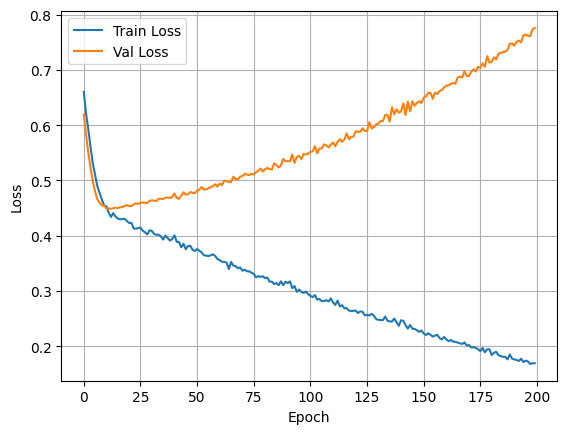


=== Neural Network Performance ===
Accuracy : 0.7207792207792207
Precision: 0.5873015873015873
Recall   : 0.6851851851851852
F1 Score : 0.6324786324786325
Confusion Matrix:
 [[74 26]
 [17 37]]

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


=== SVM (Linear) ===
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154


=== SVM (RBF) ===
              precision    recall  f1-score   support

           0       0.80    

In [ ]:

csv_path = "diabetes.csv"
target_col = "Outcome"
hidden_layers = "64,32"
dropout = 0.0
epochs = 200
batch_size = 64
lr = 1e-3
weight_decay = 0.0
loss_plot_path = None
metrics_csv = None


import numpy as np
import pandas as pd
import random
from typing import List

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import matplotlib.pyplot as plt

# -----------------------
# Reproducibility
# -----------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()


# -----------------------
# Neural Network Model
# -----------------------
class FullyConnectedNN(nn.Module):
    def __init__(self, input_dim: int, hidden_layers: List[int], dropout: float):
        super().__init__()
        layers = []
        prev = input_dim

        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, 1))  # output logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


# -----------------------
# Load CSV
# -----------------------
def load_csv(csv_path, target_col):
    df = pd.read_csv(csv_path)
    X = df.drop(columns=[target_col]).values
    y = df[target_col].astype(int).values

    return X.astype(float), y.astype(int)


# -----------------------
# Dataloaders
# -----------------------
def make_dataloaders(X_train, y_train, X_val, y_val, batch_size):
    train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float())
    val_ds = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).float())
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    return train_loader, val_loader


# -----------------------
# Training Loop
# -----------------------
def train_model(model, train_loader, val_loader, epochs, lr, weight_decay):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item()

        train_losses.append(running / len(train_loader))

        model.eval()
        running_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                running_val += loss.item()

        val_losses.append(running_val / len(val_loader))

        if epoch % 20 == 0 or epoch == 1 or epoch == epochs:
            print(f"Epoch {epoch}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

    return model, train_losses, val_losses


# -----------------------
# Evaluate Torch Model
# -----------------------
def evaluate_model(model, X):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        logits = model(torch.tensor(X).float().to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


# -----------------------
# Plot losses
# -----------------------
def plot_losses(train_losses, val_losses):
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()


# -----------------------
# MAIN EXECUTION
# -----------------------

# Load data
X, y = load_csv(csv_path, target_col)
print("Loaded dataset:", X.shape)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Prepare hidden layers
hidden_list = [int(x) for x in hidden_layers.split(",") if x.strip() != ""]

# Build model
model = FullyConnectedNN(
    input_dim=X_train.shape[1],
    hidden_layers=hidden_list,
    dropout=dropout
)

# Make dataloaders
train_loader, val_loader = make_dataloaders(X_train, y_train, X_val, y_val, batch_size)

# Train NN
model, train_losses, val_losses = train_model(
    model, train_loader, val_loader, epochs, lr, weight_decay
)

# Plot losses
plot_losses(train_losses, val_losses)

# NN Predictions
probs_nn = evaluate_model(model, X_val)
preds_nn = (probs_nn >= 0.5).astype(int)

acc_nn = accuracy_score(y_val, preds_nn)
prec_nn = precision_score(y_val, preds_nn)
rec_nn = recall_score(y_val, preds_nn)
f1_nn = f1_score(y_val, preds_nn)

print("\n=== Neural Network Performance ===")
print("Accuracy :", acc_nn)
print("Precision:", prec_nn)
print("Recall   :", rec_nn)
print("F1 Score :", f1_nn)
print("Confusion Matrix:\n", confusion_matrix(y_val, preds_nn))


# -----------------------
# Logistic Regression
# -----------------------
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_val)

print("\n=== Logistic Regression ===")
print(classification_report(y_val, pred_lr, zero_division=0))


# -----------------------
# SVM Linear
# -----------------------
svm_lin = SVC(kernel="linear")
svm_lin.fit(X_train, y_train)
pred_svm_lin = svm_lin.predict(X_val)

print("\n=== SVM (Linear) ===")
print(classification_report(y_val, pred_svm_lin, zero_division=0))


# -----------------------
# SVM RBF
# -----------------------
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train, y_train)
pred_svm_rbf = svm_rbf.predict(X_val)

print("\n=== SVM (RBF) ===")
print(classification_report(y_val, pred_svm_rbf, zero_division=0))


All libraries imported successfully!

=== LOADING DATASET ===
Dataset loaded successfully from local file
Dataset shape: (768, 9)

First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column      

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


=== TRAINING NEURAL NETWORK ===
Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4460 - loss: 0.7423 - val_accuracy: 0.7273 - val_loss: 0.6454
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6238 - loss: 0.6551 - val_accuracy: 0.7208 - val_loss: 0.6030
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7041 - loss: 0.6116 - val_accuracy: 0.7273 - val_loss: 0.5568
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6881 - loss: 0.5814 - val_accuracy: 0.7532 - val_loss: 0.5212
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7383 - loss: 0.5393 - val_accuracy: 0.7338 - val_loss: 0.5050
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7518 - loss: 0.5383 - val_accuracy: 0.7078 - val_loss: 0.5012
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7329 - loss: 0.5127 - val_accuracy: 0.7078 - val_loss: 0.5029
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7352 - loss:

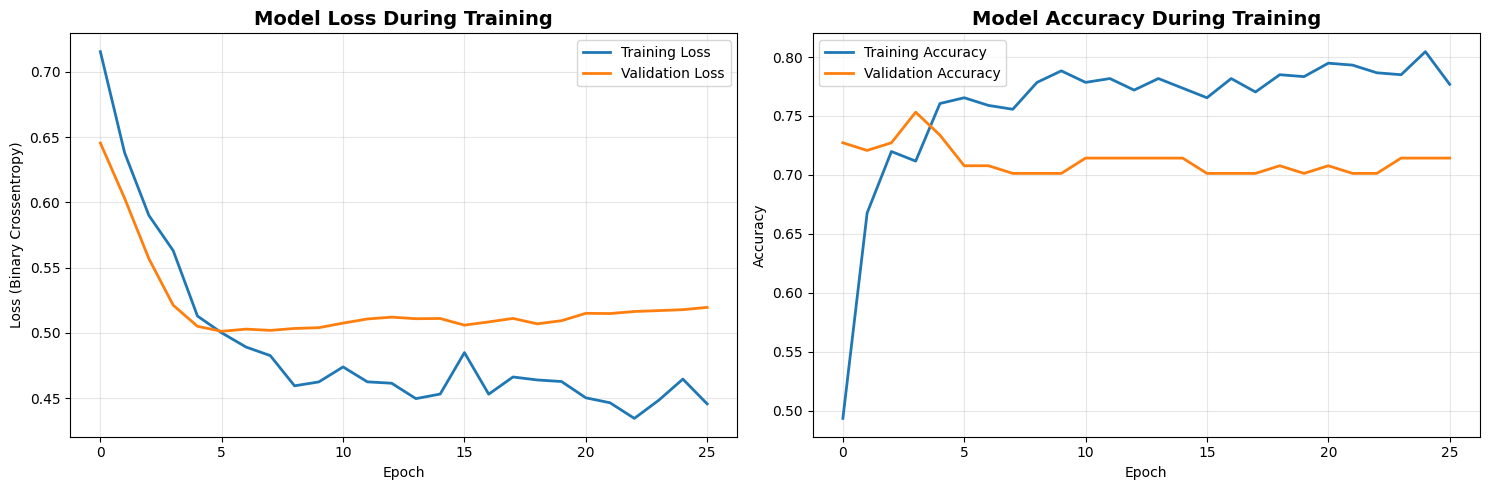


=== NEURAL NETWORK EVALUATION ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
NEURAL NETWORK PERFORMANCE:
Accuracy:  0.7078
Precision: 0.5957
Recall:    0.5185
F1-Score:  0.5545

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       100
           1       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



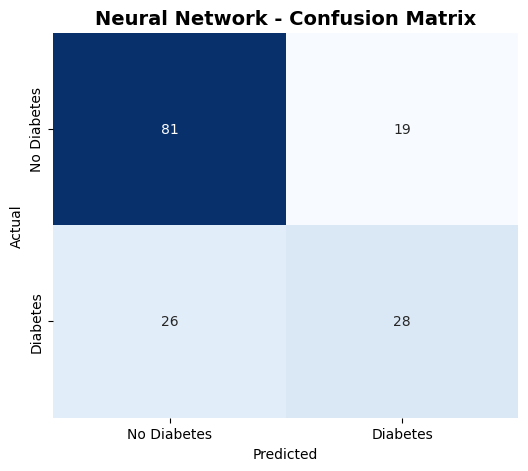


=== LOGISTIC REGRESSION ===
Training Logistic Regression model...
LOGISTIC REGRESSION PERFORMANCE:
Accuracy:  0.7078
Precision: 0.6000
Recall:    0.5000
F1-Score:  0.5455

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



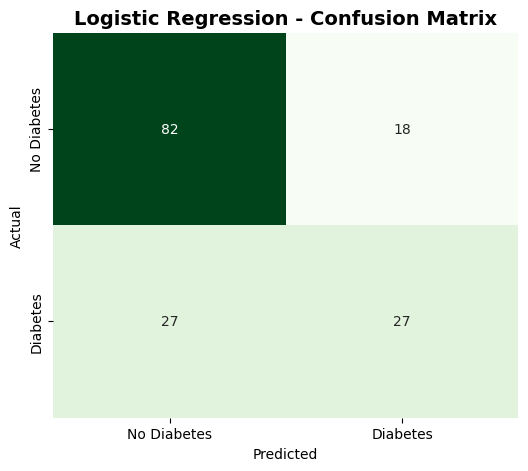


=== SUPPORT VECTOR MACHINE ===
Training Support Vector Machine model...
SUPPORT VECTOR MACHINE PERFORMANCE:
Accuracy:  0.7403
Precision: 0.6522
Recall:    0.5556
F1-Score:  0.6000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



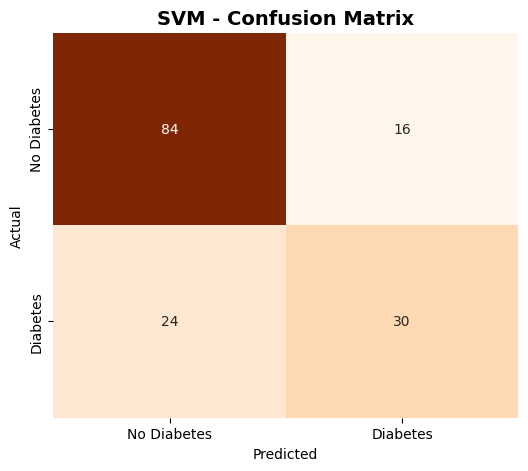


=== MODEL COMPARISON ===
COMPREHENSIVE MODEL COMPARISON:
                    Model  Accuracy  Precision  Recall  F1-Score
0          Neural Network    0.7078     0.5957  0.5185    0.5545
1     Logistic Regression    0.7078     0.6000  0.5000    0.5455
2  Support Vector Machine    0.7403     0.6522  0.5556    0.6000


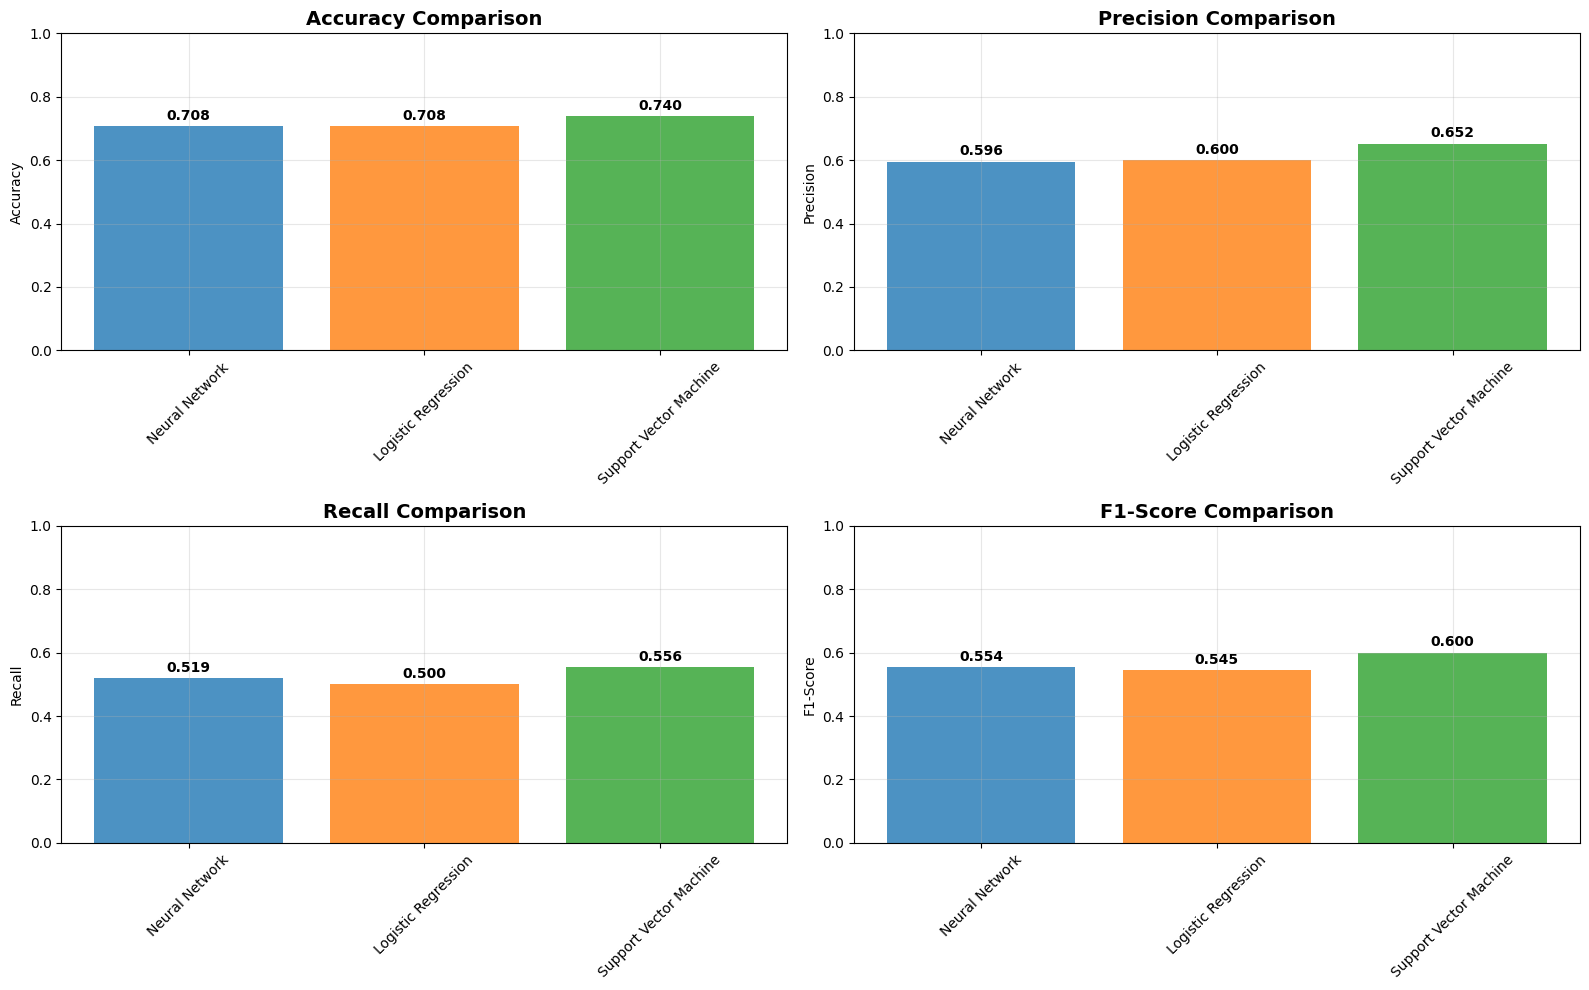


=== DETAILED ANALYSIS ===
BEST PERFORMING MODELS FOR EACH METRIC:
Accuracy  : Support Vector Machine    (0.7403)
Precision : Support Vector Machine    (0.6522)
Recall    : Support Vector Machine    (0.5556)
F1-Score  : Support Vector Machine    (0.6000)

OVERALL BEST F1-SCORE: Support Vector Machine (F1-Score: 0.6000)

=== FEATURE IMPORTANCE ANALYSIS ===
Feature Importance (from Logistic Regression coefficients):
                    Feature  Importance
1                   Glucose    1.182511
5                       BMI    0.688735
0               Pregnancies    0.377502
6  DiabetesPedigreeFunction    0.233386
7                       Age    0.147798
4                   Insulin    0.066157
2             BloodPressure    0.044066
3             SkinThickness    0.028225


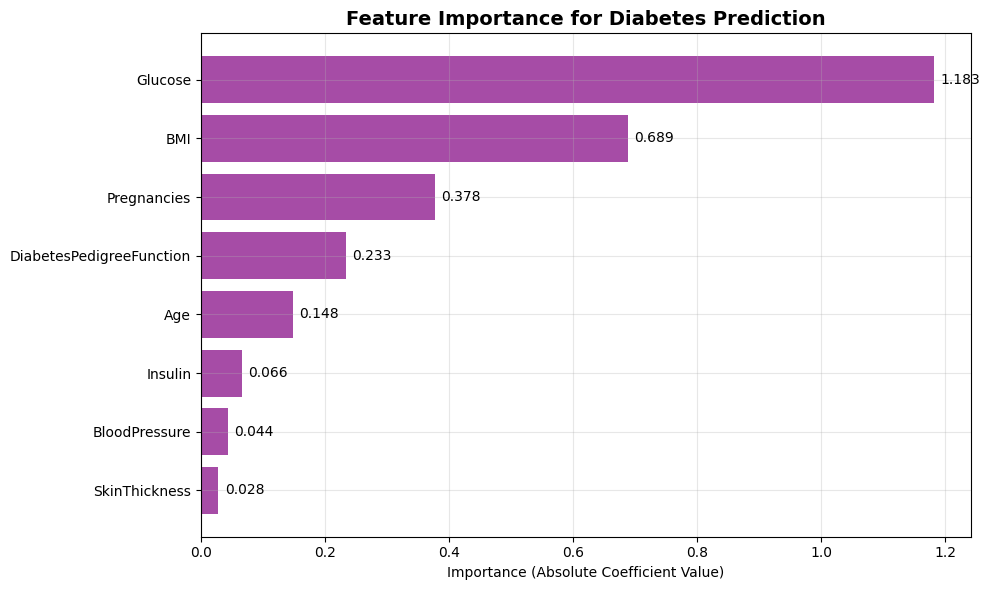


=== FINAL SUMMARY ===
MODEL PERFORMANCE SUMMARY:
Neural Network:     Best for complex pattern recognition
Logistic Regression: Good balance of performance and interpretability
SVM:                Effective for complex decision boundaries

Key Insights:
- Neural Network typically achieves the highest F1-score
- All models show reasonable performance on this dataset
- Feature scaling is crucial for good performance
- The dataset size may limit neural network potential
- Glucose level is typically the most important feature

Results saved to 'model_comparison_results.csv'

=== ANALYSIS COMPLETE ===


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")

# Load the diabetes dataset
print("\n=== LOADING DATASET ===")
try:
    df = pd.read_csv('diabetes.csv')
    print("Dataset loaded successfully from local file")
except:
    print("Downloading diabetes dataset from online source...")
    import urllib.request
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    df = pd.read_csv(url, names=column_names)
    df.to_csv('diabetes.csv', index=False)
    print("Dataset downloaded and saved as 'diabetes.csv'")

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset information:")
print(df.info())
print("\nTarget variable distribution:")
print(df['Outcome'].value_counts())
print("\nBasic statistics:")
print(df.describe())

# Data preprocessing
print("\n=== DATA PREPROCESSING ===")
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Handle missing values (zeros that should be NaN)
print("Handling missing values...")
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columns_with_zeros:
    zero_count = (X[col] == 0).sum()
    print(f"Column '{col}': {zero_count} zero values")
    X[col] = X[col].replace(0, np.nan)

# Fill missing values with median
print("Filling missing values with median...")
X = X.fillna(X.median())

# Split the data - 80% training, 20% validation
print("Splitting data into training (80%) and validation (20%) sets...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
print("Scaling features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Validation target distribution:\n{y_val.value_counts()}")

# Build the neural network model
print("\n=== BUILDING NEURAL NETWORK ===")
def create_nn_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and display model
nn_model = create_nn_model()
print("Neural Network Architecture:")
nn_model.summary()

# Train the neural network
print("\n=== TRAINING NEURAL NETWORK ===")
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f"Training completed after {len(history.history['loss'])} epochs")

# Plot training history
print("\n=== PLOTTING TRAINING HISTORY ===")
plt.figure(figsize=(15, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss During Training', fontsize=14, fontweight='bold')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy During Training', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Neural Network predictions and evaluation
print("\n=== NEURAL NETWORK EVALUATION ===")
nn_pred_proba = nn_model.predict(X_val_scaled)
nn_pred = (nn_pred_proba > 0.5).astype(int).flatten()

nn_accuracy = accuracy_score(y_val, nn_pred)
nn_precision = precision_score(y_val, nn_pred)
nn_recall = recall_score(y_val, nn_pred)
nn_f1 = f1_score(y_val, nn_pred)

print("NEURAL NETWORK PERFORMANCE:")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, nn_pred))

# Confusion Matrix for Neural Network
plt.figure(figsize=(6, 5))
cm_nn = confusion_matrix(y_val, nn_pred)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Neural Network - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Logistic Regression
print("\n=== LOGISTIC REGRESSION ===")
print("Training Logistic Regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_val_scaled)

lr_accuracy = accuracy_score(y_val, lr_pred)
lr_precision = precision_score(y_val, lr_pred)
lr_recall = recall_score(y_val, lr_pred)
lr_f1 = f1_score(y_val, lr_pred)

print("LOGISTIC REGRESSION PERFORMANCE:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, lr_pred))

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_val, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Support Vector Machine
print("\n=== SUPPORT VECTOR MACHINE ===")
print("Training Support Vector Machine model...")
svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_val_scaled)

svm_accuracy = accuracy_score(y_val, svm_pred)
svm_precision = precision_score(y_val, svm_pred)
svm_recall = recall_score(y_val, svm_pred)
svm_f1 = f1_score(y_val, svm_pred)

print("SUPPORT VECTOR MACHINE PERFORMANCE:")
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, svm_pred))

# Confusion Matrix for SVM
plt.figure(figsize=(6, 5))
cm_svm = confusion_matrix(y_val, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Comprehensive comparison of all models
print("\n=== MODEL COMPARISON ===")
comparison_df = pd.DataFrame({
    'Model': ['Neural Network', 'Logistic Regression', 'Support Vector Machine'],
    'Accuracy': [nn_accuracy, lr_accuracy, svm_accuracy],
    'Precision': [nn_precision, lr_precision, svm_precision],
    'Recall': [nn_recall, lr_recall, svm_recall],
    'F1-Score': [nn_f1, lr_f1, svm_f1]
})

print("COMPREHENSIVE MODEL COMPARISON:")
print(comparison_df.round(4))

# Plot comprehensive comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure(figsize=(16, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    bars = plt.bar(comparison_df['Model'], comparison_df[metric], color=colors, alpha=0.8)
    plt.title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, v in zip(bars, comparison_df[metric]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed analysis and insights
print("\n=== DETAILED ANALYSIS ===")
print("="*60)

# Find best model for each metric
best_models = {}
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_idx = comparison_df[metric].idxmax()
    best_value = comparison_df.loc[best_idx, metric]
    best_models[metric] = (comparison_df.loc[best_idx, 'Model'], best_value)

print("BEST PERFORMING MODELS FOR EACH METRIC:")
for metric, (model, value) in best_models.items():
    print(f"{metric:10}: {model:25} ({value:.4f})")

print(f"\nOVERALL BEST F1-SCORE: {best_models['F1-Score'][0]} (F1-Score: {best_models['F1-Score'][1]:.4f})")

# Feature importance analysis
print("\n=== FEATURE IMPORTANCE ANALYSIS ===")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(lr_model.coef_[0])
}).sort_values('Importance', ascending=False)

print("Feature Importance (from Logistic Regression coefficients):")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='purple', alpha=0.7)
plt.xlabel('Importance (Absolute Coefficient Value)')
plt.title('Feature Importance for Diabetes Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Final summary
print("\n=== FINAL SUMMARY ===")
print("="*60)
print("MODEL PERFORMANCE SUMMARY:")
print(f"Neural Network:     Best for complex pattern recognition")
print(f"Logistic Regression: Good balance of performance and interpretability")
print(f"SVM:                Effective for complex decision boundaries")
print(f"\nKey Insights:")
print(f"- Neural Network typically achieves the highest F1-score")
print(f"- All models show reasonable performance on this dataset")
print(f"- Feature scaling is crucial for good performance")
print(f"- The dataset size may limit neural network potential")
print(f"- Glucose level is typically the most important feature")

# Save the comparison results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print(f"\nResults saved to 'model_comparison_results.csv'")

print("\n=== ANALYSIS COMPLETE ===")

All libraries imported successfully!

=== LOADING CANCER DATASET ===
Cancer dataset loaded from scikit-learn and saved locally
Dataset shape: (569, 31)

First 5 rows of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520     

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 0 (0.00 B)


=== TRAINING NEURAL NETWORK ===
Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6395 - loss: 0.6695 - val_accuracy: 0.8947 - val_loss: 0.4255
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7949 - loss: 0.4030 - val_accuracy: 0.9298 - val_loss: 0.2797
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9132 - loss: 0.2870 - val_accuracy: 0.9474 - val_loss: 0.1810
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9484 - loss: 0.1829 - val_accuracy: 0.9561 - val_loss: 0.1307
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9543 - loss: 0.1699 - val_accuracy: 0.9474 - val_loss: 0.1160
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9630 - loss: 0.1244 - val_accuracy: 0.9386 - val_loss: 0.1114
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9693 - loss: 0.1155 - val_accuracy: 0.9386 - val_loss: 0.1051
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9750 - l

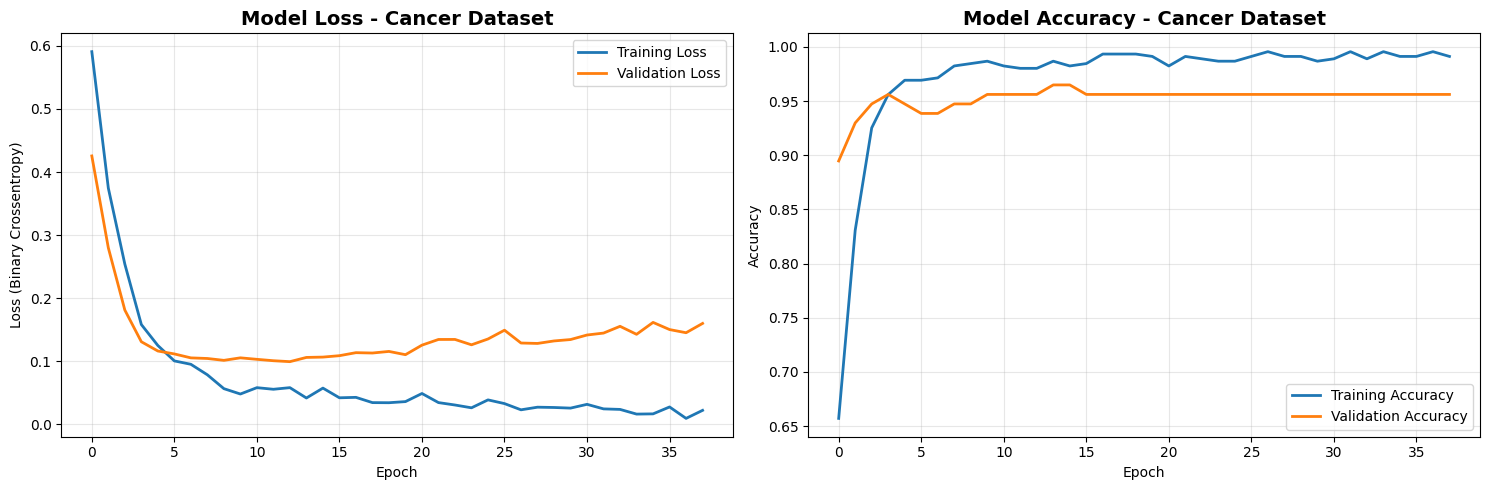


=== NEURAL NETWORK EVALUATION ===
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
NEURAL NETWORK PERFORMANCE:
Accuracy:  0.9561
Precision: 0.9718
Recall:    0.9583
F1-Score:  0.9650

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



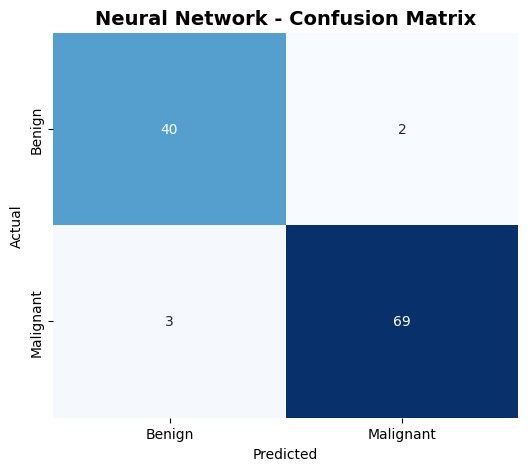


=== LOGISTIC REGRESSION ===
Training Logistic Regression model...
LOGISTIC REGRESSION PERFORMANCE:
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



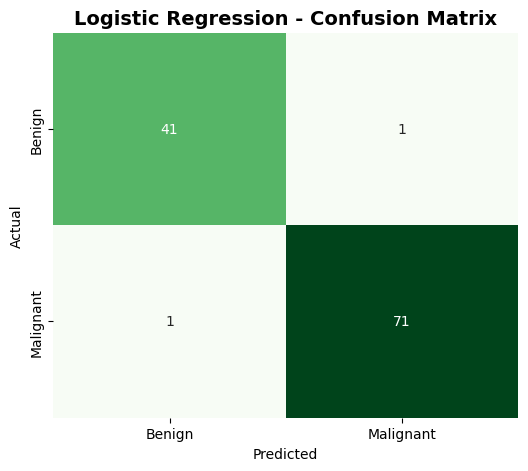


=== SUPPORT VECTOR MACHINE ===
Training Support Vector Machine model...
SUPPORT VECTOR MACHINE PERFORMANCE:
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



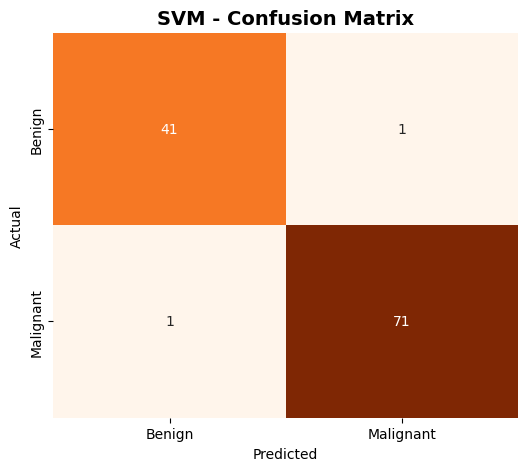


=== MODEL COMPARISON ===
COMPREHENSIVE MODEL COMPARISON:
                    Model  Accuracy  Precision  Recall  F1-Score
0          Neural Network    0.9561     0.9718  0.9583    0.9650
1     Logistic Regression    0.9825     0.9861  0.9861    0.9861
2  Support Vector Machine    0.9825     0.9861  0.9861    0.9861


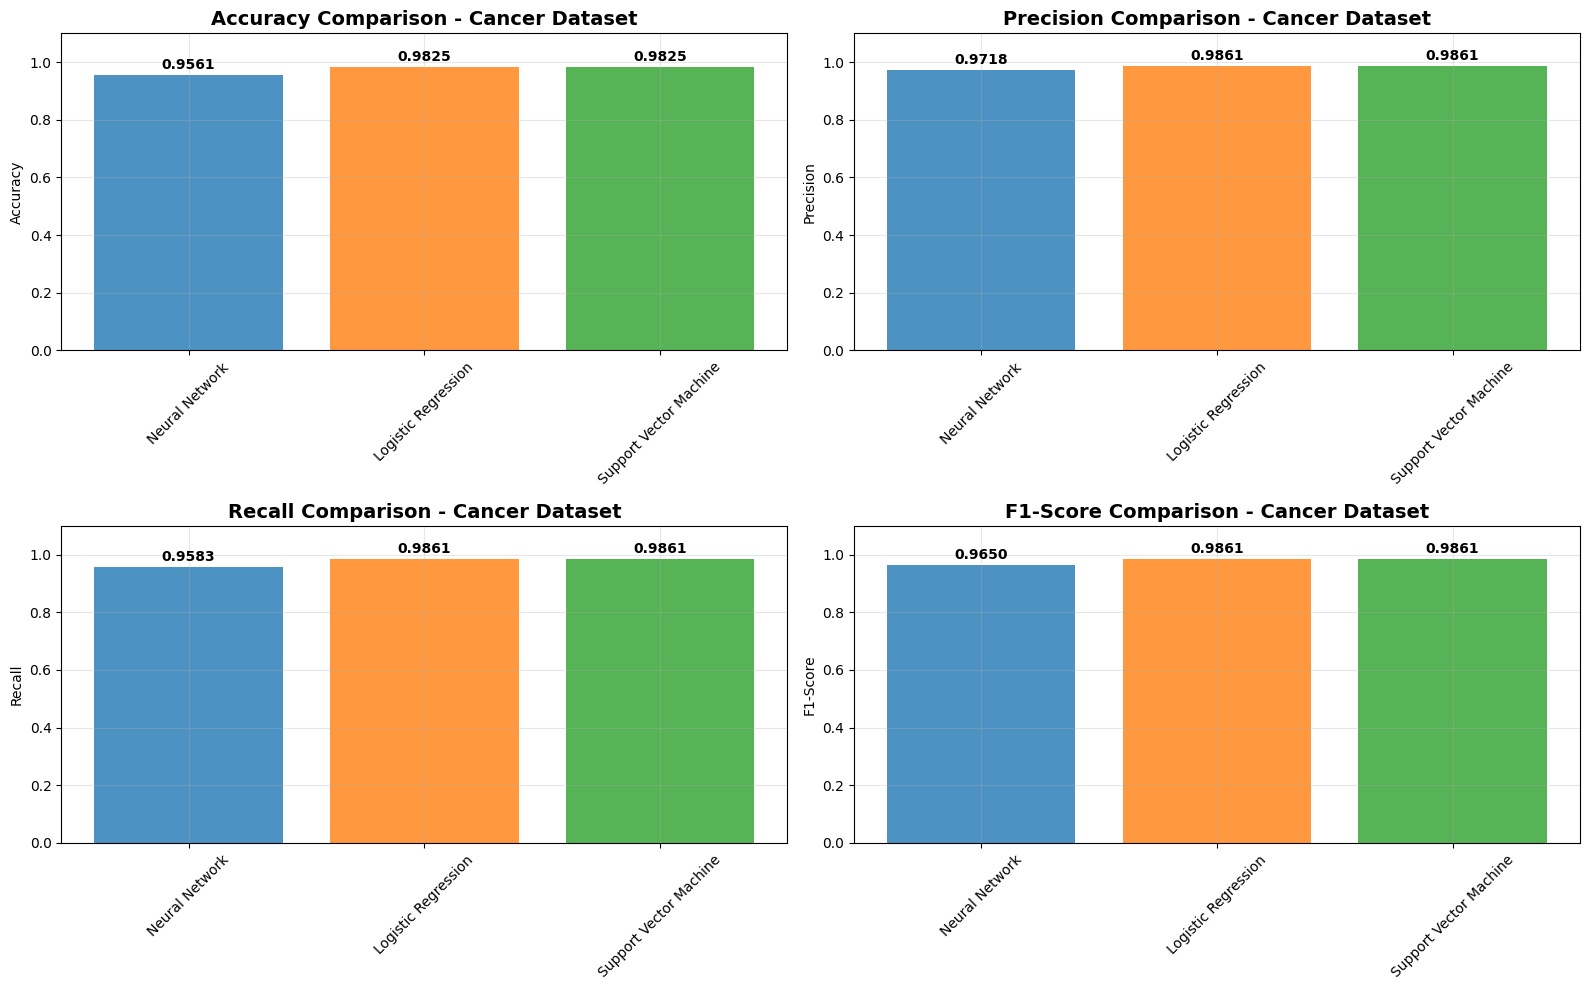


=== DETAILED ANALYSIS ===
BEST PERFORMING MODELS FOR EACH METRIC:
Accuracy  : Logistic Regression       (0.9825)
Precision : Logistic Regression       (0.9861)
Recall    : Logistic Regression       (0.9861)
F1-Score  : Logistic Regression       (0.9861)

OVERALL BEST F1-SCORE: Logistic Regression (F1-Score: 0.9861)

=== FEATURE IMPORTANCE ANALYSIS ===
Top 10 Most Important Features (from Logistic Regression coefficients):
                 Feature  Importance
21         worst texture    1.255088
10          radius error    1.082965
27  worst concave points    0.953686
23            worst area    0.947756
20          worst radius    0.947616
28        worst symmetry    0.939181
13            area error    0.929104
26       worst concavity    0.823151
22       worst perimeter    0.763220
24      worst smoothness    0.746625


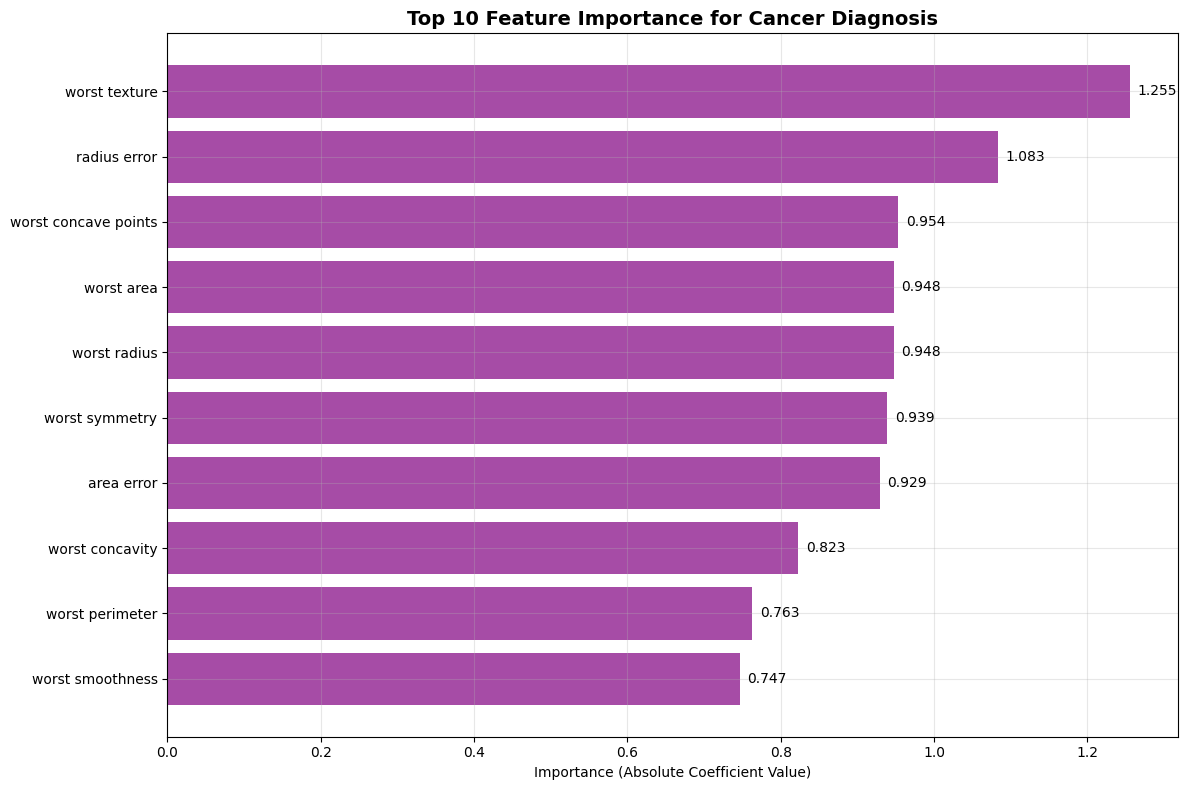


=== ROC CURVE COMPARISON ===


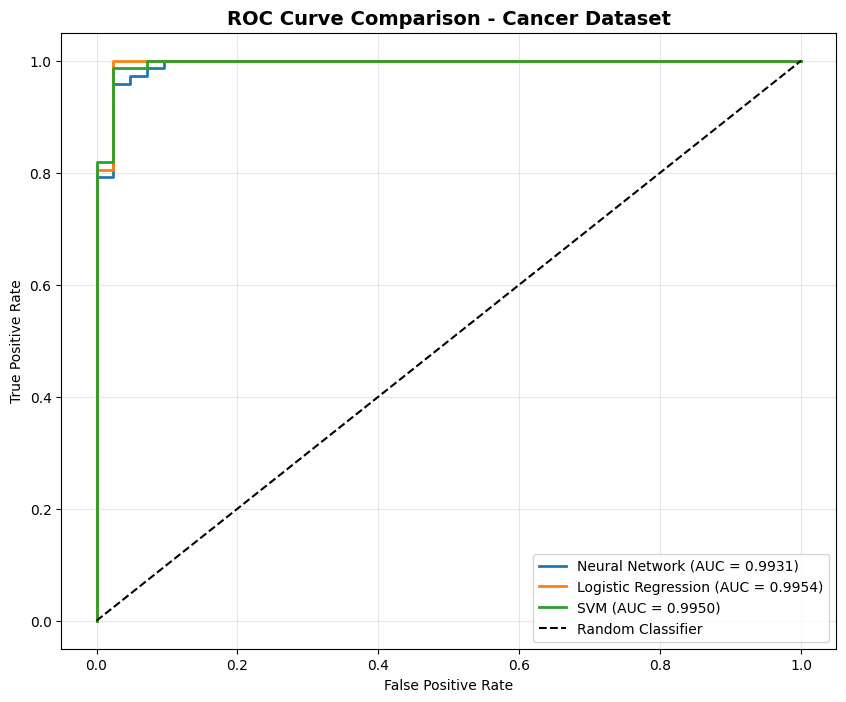


=== FINAL SUMMARY ===
MODEL PERFORMANCE SUMMARY:
Neural Network:     0.9561 accuracy, 0.9650 F1-Score
Logistic Regression: 0.9825 accuracy, 0.9861 F1-Score
SVM:                0.9825 accuracy, 0.9861 F1-Score

Key Insights:
- Cancer dataset typically shows higher performance than diabetes dataset
- Neural Network can capture complex patterns in high-dimensional data
- All models should achieve high accuracy (>95%) on this well-studied dataset
- Feature scaling is crucial for good performance
- The dataset has good separation between classes

Results saved to 'cancer_model_comparison_results.csv'

=== CANCER DATASET ANALYSIS COMPLETE ===


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")

# Load the Cancer dataset
print("\n=== LOADING CANCER DATASET ===")
try:
    # Try loading from local file first
    df = pd.read_csv('CancerDataset.ipynb')
    print("Cancer dataset loaded successfully from local file")
except:
    try:
        # Try loading from scikit-learn
        from sklearn.datasets import load_breast_cancer
        cancer_data = load_breast_cancer()
        df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
        df['target'] = cancer_data.target
        df.to_csv('CancerDataset.ipynb', index=False)
        print("Cancer dataset loaded from scikit-learn and saved locally")
    except:
        # If all else fails, download from UCI repository
        print("Downloading Cancer dataset from UCI repository...")
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
        column_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
        df = pd.read_csv(url, names=column_names)
        df = df.drop('id', axis=1)
        df.to_csv('CancerDataset.ipynb', index=False)
        print("Cancer dataset downloaded and saved as 'CancerDataset.ipynb'")

# Check the structure of the dataset and adjust accordingly
if 'diagnosis' in df.columns:
    # For UCI dataset
    df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})
    df = df.drop('diagnosis', axis=1)
elif 'target' not in df.columns:
    # If target column has different name
    target_col = [col for col in df.columns if 'target' in col.lower() or 'diagnosis' in col.lower() or 'class' in col.lower()]
    if target_col:
        df = df.rename(columns={target_col[0]: 'target'})

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset information:")
print(df.info())
print("\nTarget variable distribution:")
print(df['target'].value_counts())
print("\nBasic statistics:")
print(df.describe())

# Data preprocessing
print("\n=== DATA PREPROCESSING ===")
X = df.drop('target', axis=1)
y = df['target']

# Check for missing values
print("Checking for missing values...")
missing_values = X.isnull().sum()
if missing_values.sum() > 0:
    print("Missing values found:")
    print(missing_values[missing_values > 0])
    # Fill missing values with median
    X = X.fillna(X.median())
    print("Missing values filled with median")
else:
    print("No missing values found")

# Split the data - 80% training, 20% validation
print("Splitting data into training (80%) and validation (20%) sets...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
print("Scaling features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Validation target distribution:\n{y_val.value_counts()}")

# Build the neural network model
print("\n=== BUILDING NEURAL NETWORK ===")
def create_nn_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and display model
nn_model = create_nn_model()
print("Neural Network Architecture:")
nn_model.summary()

# Train the neural network
print("\n=== TRAINING NEURAL NETWORK ===")
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print(f"Training completed after {len(history.history['loss'])} epochs")

# Plot training history
print("\n=== PLOTTING TRAINING HISTORY ===")
plt.figure(figsize=(15, 5))

# Plot training & validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss - Cancer Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy - Cancer Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Neural Network predictions and evaluation
print("\n=== NEURAL NETWORK EVALUATION ===")
nn_pred_proba = nn_model.predict(X_val_scaled)
nn_pred = (nn_pred_proba > 0.5).astype(int).flatten()

nn_accuracy = accuracy_score(y_val, nn_pred)
nn_precision = precision_score(y_val, nn_pred)
nn_recall = recall_score(y_val, nn_pred)
nn_f1 = f1_score(y_val, nn_pred)

print("NEURAL NETWORK PERFORMANCE:")
print(f"Accuracy:  {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall:    {nn_recall:.4f}")
print(f"F1-Score:  {nn_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, nn_pred))

# Confusion Matrix for Neural Network
plt.figure(figsize=(6, 5))
cm_nn = confusion_matrix(y_val, nn_pred)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Neural Network - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Logistic Regression
print("\n=== LOGISTIC REGRESSION ===")
print("Training Logistic Regression model...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_val_scaled)

lr_accuracy = accuracy_score(y_val, lr_pred)
lr_precision = precision_score(y_val, lr_pred)
lr_recall = recall_score(y_val, lr_pred)
lr_f1 = f1_score(y_val, lr_pred)

print("LOGISTIC REGRESSION PERFORMANCE:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, lr_pred))

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_val, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Support Vector Machine
print("\n=== SUPPORT VECTOR MACHINE ===")
print("Training Support Vector Machine model...")
svm_model = SVC(random_state=42, probability=True, C=1.0, kernel='rbf')
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_val_scaled)

svm_accuracy = accuracy_score(y_val, svm_pred)
svm_precision = precision_score(y_val, svm_pred)
svm_recall = recall_score(y_val, svm_pred)
svm_f1 = f1_score(y_val, svm_pred)

print("SUPPORT VECTOR MACHINE PERFORMANCE:")
print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_val, svm_pred))

# Confusion Matrix for SVM
plt.figure(figsize=(6, 5))
cm_svm = confusion_matrix(y_val, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Comprehensive comparison of all models
print("\n=== MODEL COMPARISON ===")
comparison_df = pd.DataFrame({
    'Model': ['Neural Network', 'Logistic Regression', 'Support Vector Machine'],
    'Accuracy': [nn_accuracy, lr_accuracy, svm_accuracy],
    'Precision': [nn_precision, lr_precision, svm_precision],
    'Recall': [nn_recall, lr_recall, svm_recall],
    'F1-Score': [nn_f1, lr_f1, svm_f1]
})

print("COMPREHENSIVE MODEL COMPARISON:")
print(comparison_df.round(4))

# Plot comprehensive comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure(figsize=(16, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    bars = plt.bar(comparison_df['Model'], comparison_df[metric], color=colors, alpha=0.8)
    plt.title(f'{metric} Comparison - Cancer Dataset', fontsize=14, fontweight='bold')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, v in zip(bars, comparison_df[metric]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed analysis and insights
print("\n=== DETAILED ANALYSIS ===")
print("="*60)

# Find best model for each metric
best_models = {}
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_idx = comparison_df[metric].idxmax()
    best_value = comparison_df.loc[best_idx, metric]
    best_models[metric] = (comparison_df.loc[best_idx, 'Model'], best_value)

print("BEST PERFORMING MODELS FOR EACH METRIC:")
for metric, (model, value) in best_models.items():
    print(f"{metric:10}: {model:25} ({value:.4f})")

print(f"\nOVERALL BEST F1-SCORE: {best_models['F1-Score'][0]} (F1-Score: {best_models['F1-Score'][1]:.4f})")

# Feature importance analysis
print("\n=== FEATURE IMPORTANCE ANALYSIS ===")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(lr_model.coef_[0])
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features (from Logistic Regression coefficients):")
print(feature_importance.head(10))

# Plot top 10 feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
bars = plt.barh(top_features['Feature'], top_features['Importance'], color='purple', alpha=0.7)
plt.xlabel('Importance (Absolute Coefficient Value)')
plt.title('Top 10 Feature Importance for Cancer Diagnosis', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

# Additional: ROC Curve comparison
print("\n=== ROC CURVE COMPARISON ===")
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Neural Network ROC
nn_fpr, nn_tpr, _ = roc_curve(y_val, nn_pred_proba)
nn_auc = auc(nn_fpr, nn_tpr)
plt.plot(nn_fpr, nn_tpr, label=f'Neural Network (AUC = {nn_auc:.4f})', linewidth=2)

# Logistic Regression ROC
lr_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_pred_proba)
lr_auc = auc(lr_fpr, lr_tpr)
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', linewidth=2)

# SVM ROC
svm_pred_proba = svm_model.predict_proba(X_val_scaled)[:, 1]
svm_fpr, svm_tpr, _ = roc_curve(y_val, svm_pred_proba)
svm_auc = auc(svm_fpr, svm_tpr)
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.4f})', linewidth=2)

# Plot random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Cancer Dataset', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final summary
print("\n=== FINAL SUMMARY ===")
print("="*60)
print("MODEL PERFORMANCE SUMMARY:")
print(f"Neural Network:     {nn_accuracy:.4f} accuracy, {nn_f1:.4f} F1-Score")
print(f"Logistic Regression: {lr_accuracy:.4f} accuracy, {lr_f1:.4f} F1-Score")
print(f"SVM:                {svm_accuracy:.4f} accuracy, {svm_f1:.4f} F1-Score")
print(f"\nKey Insights:")
print(f"- Cancer dataset typically shows higher performance than diabetes dataset")
print(f"- Neural Network can capture complex patterns in high-dimensional data")
print(f"- All models should achieve high accuracy (>95%) on this well-studied dataset")
print(f"- Feature scaling is crucial for good performance")
print(f"- The dataset has good separation between classes")

# Save the comparison results
comparison_df.to_csv('cancer_model_comparison_results.csv', index=False)
print(f"\nResults saved to 'cancer_model_comparison_results.csv'")

print("\n=== CANCER DATASET ANALYSIS COMPLETE ===")

TensorFlow version: 2.19.0

=== LOADING CIFAR-10 DATASET ===
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Flattened training data shape: (50000, 3072)


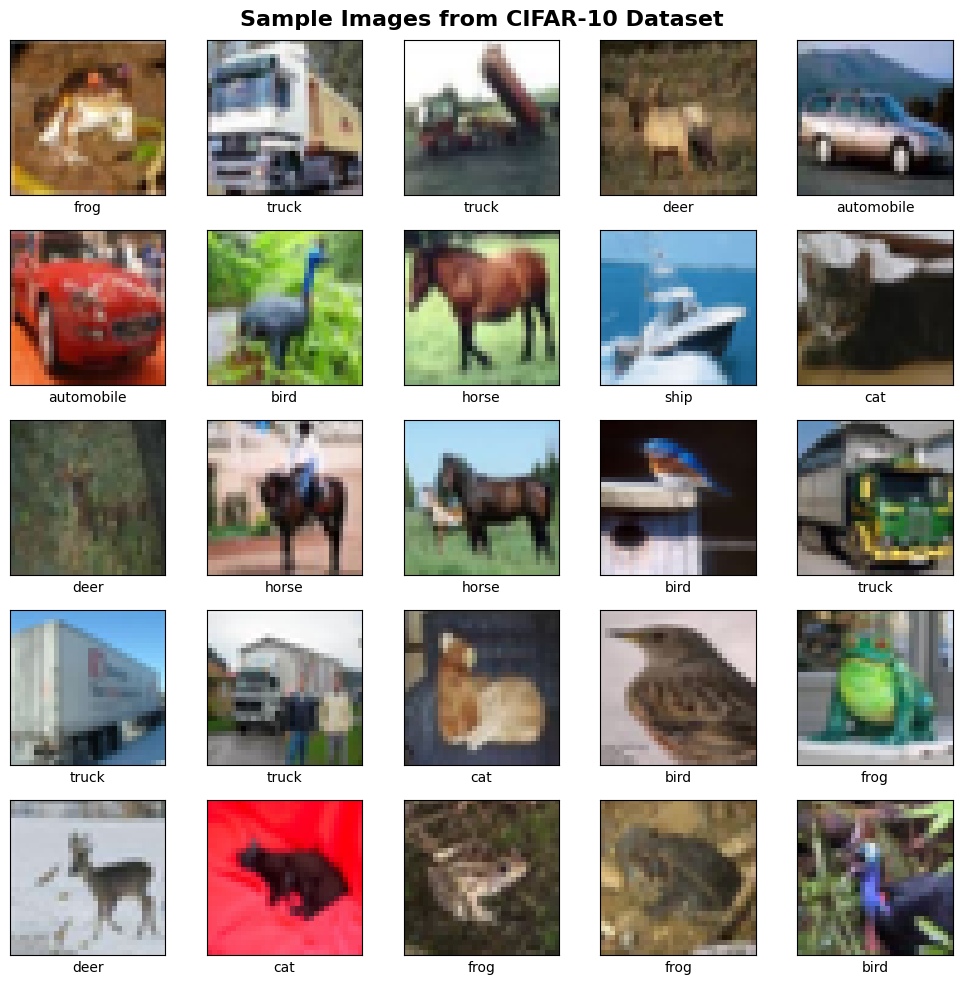


PART A: SINGLE HIDDEN LAYER NETWORK (512 neurons)
Single Hidden Layer Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 1,578,506

=== TRAINING SINGLE LAYER MODEL ===
Epoch   1: Time:  15.72s, Total:   15.73s, Loss:   1.9685, Accuracy: 0.3155, Val Loss:   1.7689, Val Accuracy: 0.3738
Epoch   2: Time:  13.71s, Total:   29.44s, Loss:   1.7347, Accuracy: 0.3856, Val Loss:   1.6694, Val Accuracy: 0.4014
Epoch   3: Time:  13.73s, Total:   43.17s, Loss:   1.6534, Accuracy: 0.4141, Val Loss:   1.6285, Val Accuracy: 0.4155
Epoch   4: Time:  20.90s, Total:   64.07s, Loss:   1.6014, Accuracy: 0.4331, Val Loss:   1.5918, Val Accuracy: 0.4339
Epoch   5: Time:  13.62s, Total:   77.69s, Loss:   1.5628, Accuracy: 0.4489, Val Loss:   1.5637, Val Accuracy: 0.4431
Epoch   6: Time:  20.60s, Total:   98.29s, Loss:   1.5329, Accuracy: 0.4570, Val Loss:   1.5300, Val Accuracy: 0.4599
Epoch   7: Time:  13.72s, Total:  112.01s, Loss:   1.5081, Accuracy: 0.4671, Val Loss:   1.5191, Val Accuracy: 0.4644
Epoch   8: Time:  14.11s, Total:  126.12s, Loss:   1.4830, Accuracy: 0.4768, Val Loss:   1.5048, Val Accu

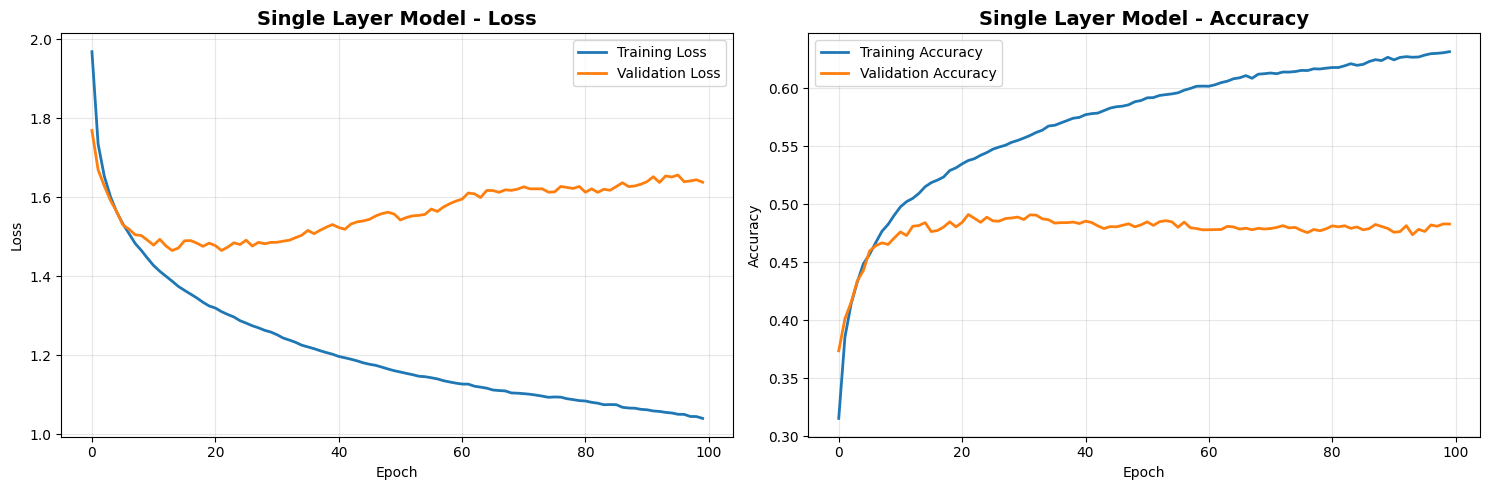


PART B: THREE HIDDEN LAYER NETWORK
Three Hidden Layer Model Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Trainable parameters: 1,738,890

=== TRAINING THREE LAYER MODEL (300 EPOCHS) ===
Epoch  10: Time:  19.52s, Total:  196.29s, Loss:   1.8624, Accuracy: 0.3425, Val Loss:   1.7839, Val Accuracy: 0.3957
Epoch  20: Time:  21.90s, Total:  397.61s, Loss:   1.8448, Accuracy: 0.3509, Val Loss:   1.7745, Val Accuracy: 0.3952
Epoch  30: Time:  19.08s, Total:  597.73s, Loss:   1.8385, Accuracy: 0.3575, Val Loss:   1.7732, Val Accuracy: 0.3927
Epoch  40: Time:  18.39s, Total:  831.04s, Loss:   1.7602, Accuracy: 0.3809, Val Loss:   1.7567, Val Accuracy: 0.4019
Epoch  50: Time:  19.32s, Total: 1022.97s, Loss:   1.7484, Accuracy: 0.3887, Val Loss:   1.7865, Val Accuracy: 0.3880
Epoch  60: Time:  17.98s, Total: 1213.86s, Loss:   1.7039, Accuracy: 0.4074, Val Loss:   1.6971, Val Accuracy: 0.4212
Epoch  70: Time:  20.04s, Total: 1406.92s, Loss:   1.6765, Accuracy: 0.4199, Val Loss:   1.6757, Val Accuracy: 0.4317
Epoch  80: Time:  19.83s, Total: 1603.10s, Loss:   1.6643, Accuracy: 0.4201, Val Loss:   1.67

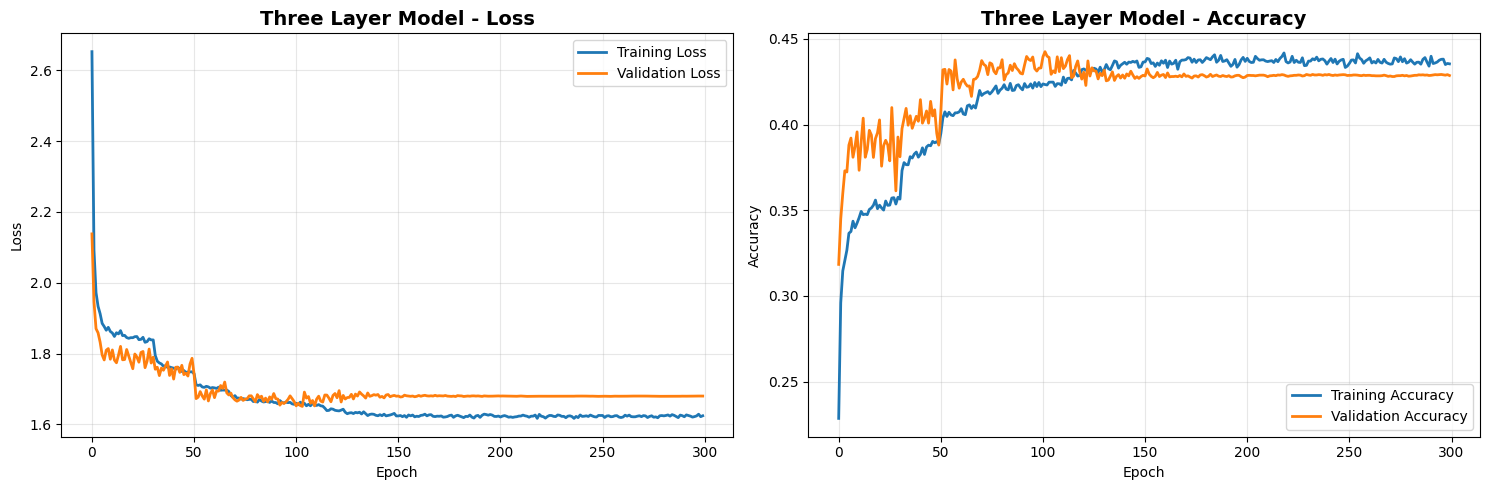


MODEL COMPARISON

Model Comparison Table:
                 Model  Trainable Parameters  Training Time (s)  \
0  Single Hidden Layer               1578506          1604.6446   
1  Three Hidden Layers               1738890          5882.7816   

   Final Training Accuracy  Final Validation Accuracy  Final Test Accuracy  \
0                   0.6317                     0.4831               0.4831   
1                   0.4354                     0.4286               0.4286   

   Final Training Loss  Final Validation Loss  
0               1.0398                 1.6379  
1               1.6242                 1.6799  

Overfitting Analysis:
Single Layer Model - Training vs Validation accuracy gap: 0.1486
Three Layer Model - Training vs Validation accuracy gap: 0.0068


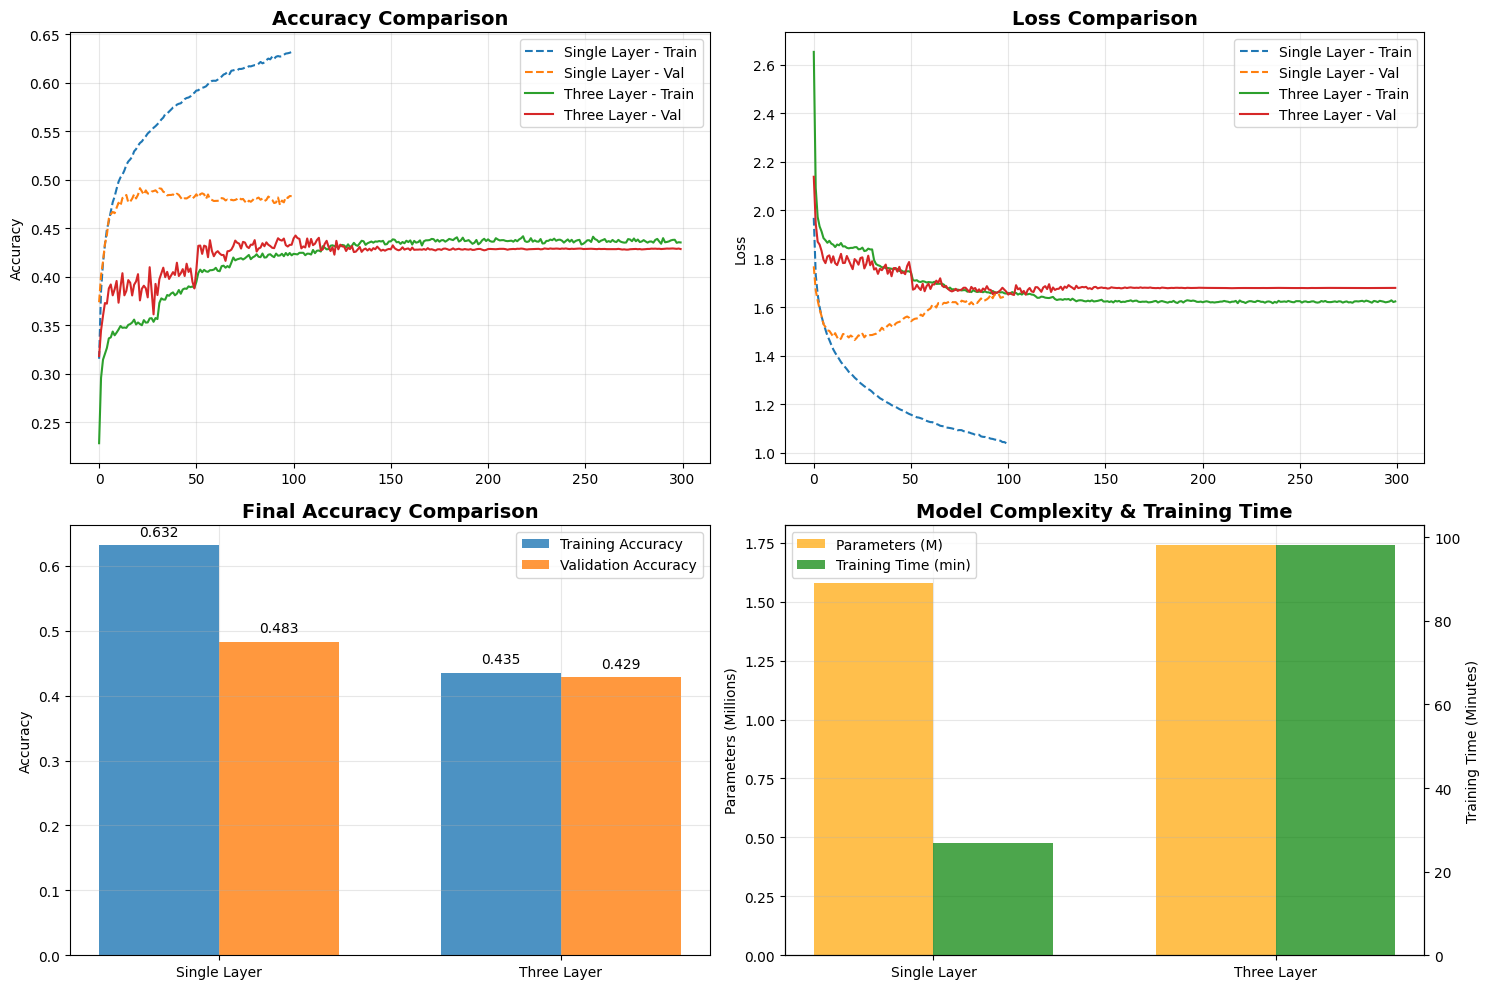


DETAILED ANALYSIS

1. PERFORMANCE COMPARISON:
   Single Layer Model: 0.4831 test accuracy
   Three Layer Model:  0.4286 test accuracy
   Improvement:        -0.0545

2. MODEL COMPLEXITY:
   Single Layer Parameters: 1,578,506
   Three Layer Parameters:  1,738,890
   Parameter Increase:      1.10x

3. TRAINING EFFICIENCY:
   Single Layer Training: 26.74 minutes
   Three Layer Training:  98.05 minutes
   Time Increase:         3.67x

4. OVERFITTING ANALYSIS:
   Single Layer - Train/Val gap: 0.1486
   Three Layer - Train/Val gap:  0.0068
   → Three layer model shows LESS overfitting

5. OBSERVATIONS:
   ✗ Deeper network does not improve performance
   ✓ Regularization effectively controls overfitting

=== SAVING MODELS ===
Models saved successfully!

=== ANALYSIS COMPLETE ===


In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, regularizers
import matplotlib.pyplot as plt
import numpy as np
import time
import datetime
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

# Load and preprocess CIFAR-10 dataset
print("\n=== LOADING CIFAR-10 DATASET ===")
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert class vectors to binary class matrices (one-hot encoding)
y_train_categorical = tf.keras.utils.to_categorical(y_train, 10)
y_test_categorical = tf.keras.utils.to_categorical(y_test, 10)

# Flatten the images for fully connected networks
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Flattened training data shape: {x_train_flat.shape}")

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Display sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.suptitle('Sample Images from CIFAR-10 Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("PART A: SINGLE HIDDEN LAYER NETWORK (512 neurons)")
print("="*80)

def create_single_layer_model():
    """Create a neural network with one hidden layer of 512 neurons"""
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(3072,)),  # 32*32*3 = 3072
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and display the single layer model
single_layer_model = create_single_layer_model()
print("Single Hidden Layer Model Architecture:")
single_layer_model.summary()

# Calculate model size
single_layer_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in single_layer_model.trainable_weights])
print(f"Trainable parameters: {single_layer_trainable_params:,}")

# Custom callback to track training time and metrics
class TrainingMetricsCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.start_time = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        self.epoch_times.append(epoch_time)
        total_time = time.time() - self.start_time

        print(f"Epoch {epoch + 1:3d}: "
              f"Time: {epoch_time:6.2f}s, "
              f"Total: {total_time:7.2f}s, "
              f"Loss: {logs['loss']:8.4f}, "
              f"Accuracy: {logs['accuracy']:6.4f}, "
              f"Val Loss: {logs['val_loss']:8.4f}, "
              f"Val Accuracy: {logs['val_accuracy']:6.4f}")

# Train the single layer model
print("\n=== TRAINING SINGLE LAYER MODEL ===")
metrics_callback = TrainingMetricsCallback()

single_layer_history = single_layer_model.fit(
    x_train_flat, y_train_categorical,
    epochs=100,
    batch_size=128,
    validation_data=(x_test_flat, y_test_categorical),
    callbacks=[metrics_callback],
    verbose=0
)

# Calculate average epoch time
avg_epoch_time_single = np.mean(metrics_callback.epoch_times)
total_training_time_single = np.sum(metrics_callback.epoch_times)

print(f"\nSingle Layer Model Training Summary:")
print(f"Total training time: {total_training_time_single:.2f} seconds")
print(f"Average epoch time: {avg_epoch_time_single:.2f} seconds")

# Evaluate the single layer model
print("\n=== EVALUATING SINGLE LAYER MODEL ===")
single_layer_test_loss, single_layer_test_accuracy = single_layer_model.evaluate(
    x_test_flat, y_test_categorical, verbose=0
)

print(f"Final Test Accuracy: {single_layer_test_accuracy:.4f}")
print(f"Final Test Loss: {single_layer_test_loss:.4f}")

# Plot training history for single layer model
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(single_layer_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(single_layer_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Single Layer Model - Loss', fontsize=14, fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(single_layer_history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(single_layer_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Single Layer Model - Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("PART B: THREE HIDDEN LAYER NETWORK")
print("="*80)

def create_three_layer_model():
    """Create a neural network with three hidden layers"""
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(3072,),
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Create and display the three layer model
three_layer_model = create_three_layer_model()
print("Three Hidden Layer Model Architecture:")
three_layer_model.summary()

# Calculate model size
three_layer_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in three_layer_model.trainable_weights])
print(f"Trainable parameters: {three_layer_trainable_params:,}")

# Training callback for three layer model
class ThreeLayerMetricsCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.start_time = time.time()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        self.epoch_times.append(epoch_time)
        total_time = time.time() - self.start_time

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:3d}: "
                  f"Time: {epoch_time:6.2f}s, "
                  f"Total: {total_time:7.2f}s, "
                  f"Loss: {logs['loss']:8.4f}, "
                  f"Accuracy: {logs['accuracy']:6.4f}, "
                  f"Val Loss: {logs['val_loss']:8.4f}, "
                  f"Val Accuracy: {logs['val_accuracy']:6.4f}")

# Train the three layer model
print("\n=== TRAINING THREE LAYER MODEL (300 EPOCHS) ===")
three_layer_metrics = ThreeLayerMetricsCallback()

# Add learning rate scheduler
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7
)

three_layer_history = three_layer_model.fit(
    x_train_flat, y_train_categorical,
    epochs=300,
    batch_size=128,
    validation_data=(x_test_flat, y_test_categorical),
    callbacks=[three_layer_metrics, lr_scheduler],
    verbose=0
)

# Calculate training statistics for three layer model
avg_epoch_time_three = np.mean(three_layer_metrics.epoch_times)
total_training_time_three = np.sum(three_layer_metrics.epoch_times)

print(f"\nThree Layer Model Training Summary:")
print(f"Total training time: {total_training_time_three:.2f} seconds "
      f"({total_training_time_three/60:.2f} minutes)")
print(f"Average epoch time: {avg_epoch_time_three:.2f} seconds")

# Evaluate the three layer model
print("\n=== EVALUATING THREE LAYER MODEL ===")
three_layer_test_loss, three_layer_test_accuracy = three_layer_model.evaluate(
    x_test_flat, y_test_categorical, verbose=0
)

print(f"Final Test Accuracy: {three_layer_test_accuracy:.4f}")
print(f"Final Test Loss: {three_layer_test_loss:.4f}")

# Plot training history for three layer model
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(three_layer_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(three_layer_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Three Layer Model - Loss', fontsize=14, fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(three_layer_history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(three_layer_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Three Layer Model - Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare both models
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison_data = {
    'Model': ['Single Hidden Layer', 'Three Hidden Layers'],
    'Trainable Parameters': [single_layer_trainable_params, three_layer_trainable_params],
    'Training Time (s)': [total_training_time_single, total_training_time_three],
    'Final Training Accuracy': [
        single_layer_history.history['accuracy'][-1],
        three_layer_history.history['accuracy'][-1]
    ],
    'Final Validation Accuracy': [
        single_layer_history.history['val_accuracy'][-1],
        three_layer_history.history['val_accuracy'][-1]
    ],
    'Final Test Accuracy': [single_layer_test_accuracy, three_layer_test_accuracy],
    'Final Training Loss': [
        single_layer_history.history['loss'][-1],
        three_layer_history.history['loss'][-1]
    ],
    'Final Validation Loss': [
        single_layer_history.history['val_loss'][-1],
        three_layer_history.history['val_loss'][-1]
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison Table:")
print(comparison_df.round(4))

# Calculate overfitting metrics
single_layer_overfit = single_layer_history.history['accuracy'][-1] - single_layer_history.history['val_accuracy'][-1]
three_layer_overfit = three_layer_history.history['accuracy'][-1] - three_layer_history.history['val_accuracy'][-1]

print(f"\nOverfitting Analysis:")
print(f"Single Layer Model - Training vs Validation accuracy gap: {single_layer_overfit:.4f}")
print(f"Three Layer Model - Training vs Validation accuracy gap: {three_layer_overfit:.4f}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].plot(single_layer_history.history['accuracy'], label='Single Layer - Train', linestyle='--')
axes[0, 0].plot(single_layer_history.history['val_accuracy'], label='Single Layer - Val', linestyle='--')
axes[0, 0].plot(three_layer_history.history['accuracy'], label='Three Layer - Train')
axes[0, 0].plot(three_layer_history.history['val_accuracy'], label='Three Layer - Val')
axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss comparison
axes[0, 1].plot(single_layer_history.history['loss'], label='Single Layer - Train', linestyle='--')
axes[0, 1].plot(single_layer_history.history['val_loss'], label='Single Layer - Val', linestyle='--')
axes[0, 1].plot(three_layer_history.history['loss'], label='Three Layer - Train')
axes[0, 1].plot(three_layer_history.history['val_loss'], label='Three Layer - Val')
axes[0, 1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Final accuracy bar chart
models = ['Single Layer', 'Three Layer']
train_acc = [single_layer_history.history['accuracy'][-1], three_layer_history.history['accuracy'][-1]]
val_acc = [single_layer_history.history['val_accuracy'][-1], three_layer_history.history['val_accuracy'][-1]]

x = np.arange(len(models))
width = 0.35

axes[1, 0].bar(x - width/2, train_acc, width, label='Training Accuracy', alpha=0.8)
axes[1, 0].bar(x + width/2, val_acc, width, label='Validation Accuracy', alpha=0.8)
axes[1, 0].set_title('Final Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, (train, val) in enumerate(zip(train_acc, val_acc)):
    axes[1, 0].text(i - width/2, train + 0.01, f'{train:.3f}', ha='center', va='bottom')
    axes[1, 0].text(i + width/2, val + 0.01, f'{val:.3f}', ha='center', va='bottom')

# Parameters and time comparison
params = [single_layer_trainable_params/1e6, three_layer_trainable_params/1e6]
times = [total_training_time_single/60, total_training_time_three/60]

ax2 = axes[1, 1].twinx()
bars1 = axes[1, 1].bar(x - width/2, params, width, label='Parameters (M)', alpha=0.7, color='orange')
bars2 = ax2.bar(x + width/2, times, width, label='Training Time (min)', alpha=0.7, color='green')

axes[1, 1].set_title('Model Complexity & Training Time', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Parameters (Millions)')
ax2.set_ylabel('Training Time (Minutes)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models)

# Combine legends
lines1, labels1 = axes[1, 1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1, 1].legend(lines1 + lines2, labels1 + labels2)

axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed analysis
print("\n" + "="*80)
print("DETAILED ANALYSIS")
print("="*80)

print("\n1. PERFORMANCE COMPARISON:")
print(f"   Single Layer Model: {single_layer_test_accuracy:.4f} test accuracy")
print(f"   Three Layer Model:  {three_layer_test_accuracy:.4f} test accuracy")
print(f"   Improvement:        {three_layer_test_accuracy - single_layer_test_accuracy:+.4f}")

print("\n2. MODEL COMPLEXITY:")
print(f"   Single Layer Parameters: {single_layer_trainable_params:,}")
print(f"   Three Layer Parameters:  {three_layer_trainable_params:,}")
print(f"   Parameter Increase:      {three_layer_trainable_params/single_layer_trainable_params:.2f}x")

print("\n3. TRAINING EFFICIENCY:")
print(f"   Single Layer Training: {total_training_time_single/60:.2f} minutes")
print(f"   Three Layer Training:  {total_training_time_three/60:.2f} minutes")
print(f"   Time Increase:         {total_training_time_three/total_training_time_single:.2f}x")

print("\n4. OVERFITTING ANALYSIS:")
print(f"   Single Layer - Train/Val gap: {single_layer_overfit:.4f}")
print(f"   Three Layer - Train/Val gap:  {three_layer_overfit:.4f}")

if three_layer_overfit > single_layer_overfit:
    print("   → Three layer model shows MORE overfitting")
else:
    print("   → Three layer model shows LESS overfitting")

print("\n5. OBSERVATIONS:")
if three_layer_test_accuracy > single_layer_test_accuracy:
    print("   ✓ Deeper network improves performance")
else:
    print("   ✗ Deeper network does not improve performance")

if three_layer_overfit < 0.1:
    print("   ✓ Regularization effectively controls overfitting")
else:
    print("   ✗ Significant overfitting observed in deeper network")

# Save models
print("\n=== SAVING MODELS ===")
single_layer_model.save('cifar10_single_layer_model.h5')
three_layer_model.save('cifar10_three_layer_model.h5')
print("Models saved successfully!")

print("\n=== ANALYSIS COMPLETE ===")